# K-Nearest Neighbors (KNN) Algorithm

---

## 1. What is KNN?

- KNN is a **simple, supervised machine learning algorithm** used for both **classification** and **regression** tasks.  
- It classifies a data point based on how its **neighbors** are classified.  
- It is an example of a **lazy learner** or **instance-based learning** — it does not learn an explicit model during training but stores all training data and performs computation during prediction.

---

## 2. How does KNN work?

### Steps:
1. Choose the number of neighbors **K**.  
2. Calculate the **distance** between the new input (query point) and all points in the training data.  
3. Select the **K closest neighbors** based on the distance metric.  

**For classification:**  
- Assign the class that appears most frequently among the K neighbors (**majority voting**).

**For regression:**  
- Take the **average** (or **weighted average**) of the values of the K neighbors.

---

## 3. Key Components

### a) Choosing K
- Small K (e.g., 1 or 3) can be noisy and sensitive to outliers.  
- Large K smooths the decision boundary but may miss local patterns.  
- K is usually selected using **cross-validation**.

### b) Distance Metrics
Common ways to measure distance include:

- **Euclidean Distance (most common):**
\[
d(x, y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}
\]

- **Manhattan Distance (sum of absolute differences):**
\[
d(x, y) = \sum_{i=1}^{n} |x_i - y_i|
\]

- **Minkowski Distance:**  
  A generalization of Euclidean and Manhattan distances.

- **Hamming Distance:**  
  Used for categorical variables.

---

## 4. Advantages of KNN

- Easy to understand and implement.  
- No assumptions about data distribution (**non-parametric**).  
- Works well with **multi-class** problems.  
- Naturally adapts as more data is added.

---

## 5. Disadvantages of KNN

- Computationally expensive at prediction time (distance calculated for all points).  
- Sensitive to irrelevant or redundant features (feature scaling is important).  
- Performance degrades in high-dimensional data (**curse of dimensionality**).  
- Sensitive to noisy data and outliers.  
- Requires careful selection of K and distance metric.

---

## 6. Practical Considerations

- **Feature Scaling:** Normalize or standardize features so no feature dominates the distance.  
- **Choosing K:** Use cross-validation to find the optimal K.  
- **Dimensionality Reduction:** Apply PCA or feature selection when dealing with many features.  
- **Weighted KNN:** Assign higher weight to closer neighbors using inverse distance.

---

## 7. Example (Classification)

Suppose you want to classify a new flower using petal length and width:

1. Choose **K = 3**.  
2. Calculate the distance from the new flower to every flower in the training dataset.  
3. Select the **3 nearest neighbors**.  
4. If 2 neighbors belong to *Iris-setosa* and 1 to *Iris-versicolor*,  
5. Assign the class **Iris-setosa** (majority vote).

---


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\heart.csv")

In [30]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [32]:
x = df.iloc[: , :13]
y = df.iloc[: , -1]

In [33]:
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


In [34]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train ,y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [35]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
835,49,1,2,118,149,0,0,126,0,0.8,2,3,2
137,64,0,0,180,325,0,1,154,1,0.0,2,0,2
534,54,0,2,108,267,0,0,167,0,0.0,2,0,2
495,59,1,0,135,234,0,1,161,0,0.5,1,0,3
244,51,1,2,125,245,1,0,166,0,2.4,1,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,41,1,2,130,214,0,0,168,0,2.0,1,0,2
71,61,1,0,140,207,0,0,138,1,1.9,2,1,3
106,51,1,0,140,299,0,1,173,1,1.6,2,0,3
270,43,1,0,110,211,0,1,161,0,0.0,2,0,3


In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [37]:
pipe = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
    )

In [38]:
pipe.fit(x_train ,y_train)

,steps,"[('standardscaler', ...), ('kneighborsclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30


In [39]:
y_pred = pipe.predict(x_test)

In [40]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test ,y_pred)

0.8341463414634146

In [41]:
y_pred

array([1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1])

In [42]:
y_test

527    1
359    1
447    0
31     1
621    0
      ..
832    1
796    1
644    1
404    0
842    0
Name: target, Length: 205, dtype: int64

In [43]:
train_scores = []
test_scores = []

for i in range(1, 20):
    pipe = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=i)
    )
    pipe.fit(x_train, y_train)
    
    # Training accuracy
    y_pred_train = pipe.predict(x_train)
    train_scores.append(accuracy_score(y_train, y_pred_train))
    
    # Test accuracy
    y_pred_test = pipe.predict(x_test)
    test_scores.append(accuracy_score(y_test, y_pred_test))

In [44]:
test_scores

[0.9853658536585366,
 0.975609756097561,
 0.9365853658536586,
 0.8878048780487805,
 0.8341463414634146,
 0.8146341463414634,
 0.824390243902439,
 0.8390243902439024,
 0.8390243902439024,
 0.8390243902439024,
 0.824390243902439,
 0.8195121951219512,
 0.8097560975609757,
 0.8097560975609757,
 0.7951219512195122,
 0.8048780487804879,
 0.8048780487804879,
 0.8097560975609757,
 0.8292682926829268]

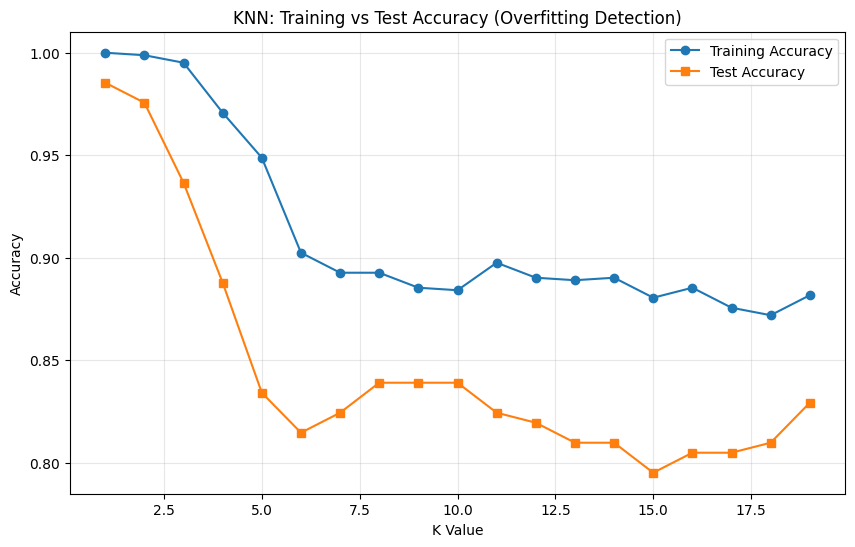

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 20), train_scores, label='Training Accuracy', marker='o')
plt.plot(range(1, 20), test_scores, label='Test Accuracy', marker='s')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN: Training vs Test Accuracy (Overfitting Detection)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()